### Calcuating Boltzmann Constant from Johnson Noise Varying Resitances

In this section of the experiment, we change the risistor in which we measure Johnson Noise. To find the uncertainties in our measurements, we look at the data sheets for our handheld multimeter, which is used to calculate the resistance of our resistor, our multimeter, which is used to calculate Johnson Noise squared, and two thermometers, measuring the temperature of the room.

Here are the datasheets we look at for error propogation:

https://www.dropbox.com/scl/fi/1vq24o1unn4n0ikm1oeed/ZT111-Eng.pdf?rlkey=g51p6y0agtyp7edrfm9i7kx83&e=1&dl=0
https://www.manualslib.com/manual/1522469/Zotek-Zt111.html
https://www.manualslib.com/manual/2894668/Protek-B8000fd-Series.html?page=2#manual
https://www.manualslib.com/manual/2894668/Protek-B8000fd-Series.html?page=2#manual
https://res.cloudinary.com/iwh/image/upload/q_auto,g_center/assets/1/26/Documents/Protek/protekb8040fd_datasheet.pdf

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import odr
import pandas as pd

In [40]:
# Data input
df = pd.read_csv("/Users/jacobbalek/Documents/The Ohio State University/PHYS 5700 Adv Physics Lab/PHYS 5700 Adv Physics Lab Spring 2026/Johnson_Noise_Data.csv")
print("Length of full df: ", len(df)) #Expect 6 * 15 = 90
print(df.head(), "\n")

# Remove NaN cols (clean)
df_clean = df.dropna()
print("Length of Cleaned df: ", len(df_clean), "\n")

print("Columns in df: ")
for col in df_clean:
    print(col)

Length of full df:  90
   Rin (Ohms)  Gain G2 (HLE)  <Vsq> Read (V)  Mean <Vsq> Read (V)  \
0         1.0         6000.0          0.8682             0.867983   
1         NaN            NaN          0.8669                  NaN   
2         NaN            NaN          0.8688                  NaN   
3         NaN            NaN          0.8666                  NaN   
4         NaN            NaN          0.8662                  NaN   

   STD <Vsq> Read (V)  
0            0.001862  
1                 NaN  
2                 NaN  
3                 NaN  
4                 NaN   

Length of Cleaned df:  15 

Columns in df: 
Rin (Ohms)
Gain G2 (HLE)
<Vsq> Read (V)
Mean <Vsq> Read (V)
STD <Vsq> Read (V)


In [41]:
# Plot values from "Mean <Vsq> Read (V)"
voltage = df_clean["Mean <Vsq> Read (V)"]
gain = df_clean["Gain G2 (HLE)"]
resistance = df_clean["Rin (Ohms)"]
std = df_clean["STD <Vsq> Read (V)"]

In [42]:
# Get Uncertainties

# Resistance uncertainty 
# From datasheet
# Range | Resolution | Accuracy

def multimeter_uncertainty(reading):
    if reading < 100:
        return reading * 0.01 + 0.03  # ohms
    elif reading < 1000:
        return reading * 0.005 + 0.3 
    elif reading < 10000:
        return reading * 0.005 + 3
    elif reading < 100000:
        return reading * 0.005 + 30
    elif reading < 1000000:
        return reading * 0.005 + 300
    elif reading < 10000000:
        return reading * 0.015 + 3000
    elif reading < 100000000:
        return reading * 0.015 + 30000
    else:
        print(f"Reading out of range for multimeter uncertainty calculation. Reading is {reading}.")
        return 0
    
def johnson_noise_uncerts(v_read_uncert, G2, G1 = 600):
    return v_read_uncert * 10 / ((G1 * G2)**2)

In [43]:
johnson_noise_uncerts_vals = []
for i in range(len(std)):
    johnson_noise_uncerts_vals.append(johnson_noise_uncerts(std.iloc[i], gain.iloc[i]))

resistance_uncerts = []
for i in range(len(resistance)):
    resistance_uncerts.append(multimeter_uncertainty(resistance.iloc[i]))

print(johnson_noise_uncerts_vals) # We are treating this as noise_tot uncertainty
print(resistance_uncerts)

[np.float64(1.436442901234568e-15), np.float64(3.5223294753086417e-15), np.float64(2.08213649691358e-14), np.float64(3.908626666666667e-15), np.float64(6.670287037037038e-15), np.float64(3.899455555555556e-14), np.float64(1.0820536458333332e-12), np.float64(3.219975308641975e-15), np.float64(2.1949413580246912e-13), np.float64(4.323927083333333e-15), np.float64(1.2404472222222222e-14), np.float64(2.9395686728395064e-15), np.float64(4.6418819444444445e-12), np.float64(6.009527160493827e-14), np.float64(2.7123400000000003e-13)]
[np.float64(0.04), np.float64(0.13), np.float64(0.8), np.float64(8.0), np.float64(80.0), np.float64(800.0), np.float64(18000.0), np.float64(1.302), np.float64(1820.5), np.float64(18.009999999999998), np.float64(181.55), np.float64(1.7965000000000002), np.float64(182850.0), np.float64(263.25), np.float64(2831.0)]


In [44]:
# <Vsq (t)> = {G1 G2}^2 / 10V <VJ^2 + VN^2>
# <VJ^2 + VN^2> = <Vsq (t)> * 10 V / {G1 G2}^2

def infer_noise(volts, G2, G1 = 600):
    return volts * 10 / ((G1 * G2)**2)

noise_tot = infer_noise(voltage, gain)
print(type(voltage))

# print(min(noise_tot))

def adjusted_noise_uncerts(inferred_noise_uncert, amplifier_noise_uncert = johnson_noise_uncerts_vals[0]):
    adjusted_noise_uncerts_vals = []
    for i in range(len(inferred_noise_uncert)):
        adjusted_noise_uncerts_vals.append(np.sqrt(inferred_noise_uncert[i]**2 + amplifier_noise_uncert**2))
    return adjusted_noise_uncerts_vals

adjusted_noise_uncerts_vals = adjusted_noise_uncerts(johnson_noise_uncerts_vals)
print(adjusted_noise_uncerts_vals)

<class 'pandas.Series'>
[np.float64(2.0314370325004823e-15), np.float64(3.80396807835387e-15), np.float64(2.0870855454112625e-14), np.float64(4.164220290508772e-15), np.float64(6.823202867053824e-15), np.float64(3.902100371830299e-14), np.float64(1.0820545992829645e-12), np.float64(3.5258487200631804e-15), np.float64(2.1949883603308986e-13), np.float64(4.556282874283673e-15), np.float64(1.248736558768061e-14), np.float64(3.2717628567557583e-15), np.float64(4.641882166700006e-12), np.float64(6.011243662903548e-14), np.float64(2.712378036413961e-13)]


In [45]:
print(noise_tot)

0     6.697402e-13
6     6.698560e-13
12    6.764146e-13
18    8.500741e-13
24    2.470165e-12
30    1.847407e-11
36    1.370862e-10
42    6.961677e-13
48    5.138117e-11
54    1.207031e-12
60    6.122454e-12
66    7.176826e-13
72    3.731250e-10
78    9.040329e-12
84    8.160556e-11
dtype: float64


In [46]:
print(type(johnson_noise_uncerts_vals))

<class 'list'>


In [47]:
print(min(noise_tot))

6.697402260802468e-13


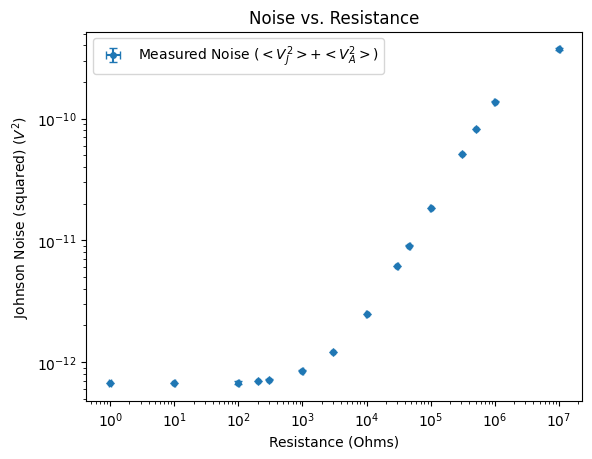

In [48]:
# Plot
plt.errorbar(resistance, noise_tot, 
             xerr=resistance_uncerts, 
             yerr=johnson_noise_uncerts_vals,
             fmt='o', label='Measured Noise ($<V_J^2> + <V_A^2>$)', capsize=3, markersize=4)
plt.xscale('log')
plt.yscale('log')
# plt.yrange(5,-5)
plt.xlabel('Resistance (Ohms)')
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Resistance')
plt.legend()
plt.savefig('amplifier_noise_plot.png', dpi=300)
plt.show()

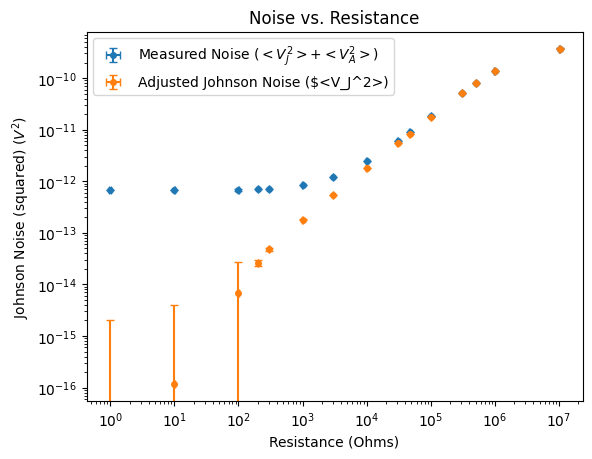

In [49]:
# Adjusted noise
# adjusted_noise = noise_tot - noise_tot[0]

adjusted_noise = noise_tot - noise_tot[0]
# print(adjusted_noise)

# Plot
# plt.scatter(resistance, noise_tot, color="blue", alpha =.5)
plt.errorbar(resistance, noise_tot, 
             xerr=resistance_uncerts, 
             yerr=johnson_noise_uncerts_vals,
             fmt='o', label='Measured Noise ($<V_J^2> + <V_A^2>$)', capsize=3, markersize=4)
# plt.scatter(resistance, adjusted_noise, color="red", alpha =.5)
plt.errorbar(resistance, adjusted_noise, 
             xerr=resistance_uncerts, 
             yerr=adjusted_noise_uncerts_vals,
             fmt='o', label='Adjusted Johnson Noise ($<V_J^2>)', capsize=3, markersize=4)
plt.xscale('log')
plt.yscale('log')
# plt.yrange(5,-5)
plt.xlabel('Resistance (Ohms)')
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Resistance')
plt.legend()
# plt.savefig('noise_vs_resistance_plot.png', dpi=300)
plt.show()

In [50]:
## Fit to line
# Plot using ODR
def linear_func(B, x):
    return B[0] * x + B[1]
linear = odr.Model(linear_func)

j = 1
k = -1

log_resistance = np.log10(resistance)
log_adjusted_noise = np.log10(adjusted_noise)
log_resistance_uncerts = np.log10(resistance_uncerts)
log_adjusted_noise_uncerts_vals = np.log10(adjusted_noise_uncerts_vals)

mydata = odr.RealData(resistance[j:k], adjusted_noise[j:k], resistance_uncerts[j:k], adjusted_noise_uncerts_vals[j:k])
# mydata = odr.RealData(log_resistance[j:k], log_adjusted_noise[j:k], log_resistance_uncerts[j:k], log_adjusted_noise_uncerts_vals[j:k])

sol = odr.ODR(mydata, linear, beta0=[9., 1.])
myoutput = sol.run()
myoutput.pprint()

Beta: [ 1.74928594e-16 -5.72546130e-16]
Beta Std Error: [8.16981484e-18 2.50701622e-14]
Beta Covariance: [[ 3.43824122e-37 -2.87731484e-34]
 [-2.87731484e-34  3.23762244e-30]]
Residual Variance: 194.12795765522813
Inverse Condition #: 0.00031359612861431746
Reason(s) for Halting:
  Sum of squares convergence


/Users/jacobbalek/miniconda3/envs/general/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [51]:
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square

print("Best Fit Slope: ", myoutput.beta[0])

print("Chi squared: ", chi_sq)
print("Reduced Chi squared: ", red_chi_sq)

Best Fit Slope:  1.7492859437714037e-16
Chi squared:  2135.4075342075093
Reduced Chi squared:  194.12795765522813


<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\O'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:43: SyntaxWarning: invalid escape sequence '\O'
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7479/16406062.py:35: SyntaxWarning: invalid escape sequence '\c'
  f"$\chi^2$: {chi_sq:.3f}\n"
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7479/16406062.py:36: SyntaxWarning: invalid escape sequence '\c'
  f"Reduced $\chi^2$: {red_chi_sq:.3f}"
/var/folders/fz/hk4chdm57f5gr20vrcsf208h0000gn/T/ipykernel_7479/16406062.py:43: SyntaxWarning: invalid escape sequence '\O'
  plt.xlabel(f'Reistance ($\Omega$)')


[1.00000000e+02 1.09749877e+02 1.20450354e+02 1.32194115e+02
 1.45082878e+02 1.59228279e+02 1.74752840e+02 1.91791026e+02
 2.10490414e+02 2.31012970e+02 2.53536449e+02 2.78255940e+02
 3.05385551e+02 3.35160265e+02 3.67837977e+02 4.03701726e+02
 4.43062146e+02 4.86260158e+02 5.33669923e+02 5.85702082e+02
 6.42807312e+02 7.05480231e+02 7.74263683e+02 8.49753436e+02
 9.32603347e+02 1.02353102e+03 1.12332403e+03 1.23284674e+03
 1.35304777e+03 1.48496826e+03 1.62975083e+03 1.78864953e+03
 1.96304065e+03 2.15443469e+03 2.36448941e+03 2.59502421e+03
 2.84803587e+03 3.12571585e+03 3.43046929e+03 3.76493581e+03
 4.13201240e+03 4.53487851e+03 4.97702356e+03 5.46227722e+03
 5.99484250e+03 6.57933225e+03 7.22080902e+03 7.92482898e+03
 8.69749003e+03 9.54548457e+03 1.04761575e+04 1.14975700e+04
 1.26185688e+04 1.38488637e+04 1.51991108e+04 1.66810054e+04
 1.83073828e+04 2.00923300e+04 2.20513074e+04 2.42012826e+04
 2.65608778e+04 2.91505306e+04 3.19926714e+04 3.51119173e+04
 3.85352859e+04 4.229242

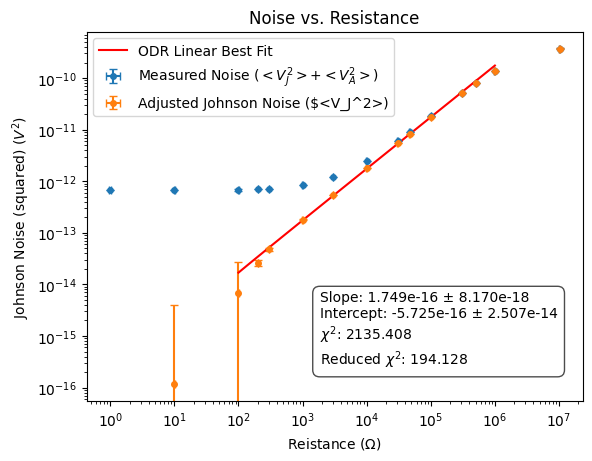

In [67]:
# Plot with best fit line
# Make a plot of time delay verus cable length

# Plot data
# plt.scatter(delta_f, noise_tot)
# ''' 
plt.errorbar(resistance, noise_tot, 
             xerr=resistance_uncerts, 
             yerr=johnson_noise_uncerts_vals,
             fmt='o', label='Measured Noise ($<V_J^2> + <V_A^2>$)', capsize=3, markersize=4)
# '''
# plt.scatter(resistance, adjusted_noise, color="red", alpha =.5)
plt.errorbar(resistance[1:], adjusted_noise[1:], 
             xerr=resistance_uncerts[1:], 
             yerr=adjusted_noise_uncerts_vals[1:],
             fmt='o', label='Adjusted Johnson Noise ($<V_J^2>)', capsize=3, markersize=4)


# Plot best fit line
x_fit = np.logspace(2, 6, 100)
print(x_fit)

y_fit = linear_func(myoutput.beta, x_fit)
plt.plot(x_fit, y_fit, color='red', label='ODR Linear Best Fit')

slope = myoutput.beta[0]
slope_err = myoutput.sd_beta[0]
intercept = myoutput.beta[1]
intercept_err = myoutput.sd_beta[1]
chi_sq = myoutput.sum_square  # Total weighted sum of squares
red_chi_sq = myoutput.res_var # Reduced Chi-Square
stats_text = (
    f"Slope: {slope:.3e} ± {slope_err:.3e}\n"
    f"Intercept: {intercept:.3e} ± {intercept_err:.3e}\n"
    f"$\chi^2$: {chi_sq:.3f}\n"
    f"Reduced $\chi^2$: {red_chi_sq:.3f}"
)

plt.text(0.47, 0.3, stats_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top', 
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.7))

plt.xlabel(f'Reistance ($\Omega$)')
plt.xscale('log')
plt.yscale('log')
# plt.ylim(0,0.2E-10)
# plt.xlim(1,1E8)
# plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) # sci notation for y ticks
plt.ylabel(f'Johnson Noise (squared) ($V^2$)')
plt.title('Noise vs. Resistance')
plt.legend()
plt.savefig('noise_vs_resistance_plot.png', dpi=300)
plt.show()

## Calculate Boltsmann Constant

Recall Johnson Noise Squared = 4 kb T R delta f

kb = Vj^2 / (4 * T * R * delta f); our slope is Vj^2 /delta_f, so multiply slope / (4 * T * R)

Recal Boltzmann constant is ~ 1.380649 × 10-23

In [53]:
delta_f = 10996
T = 294.817 # ~ 71 degrees F; Adjust in future
print("Slope: ", slope)
print("Calculated Boltzmann constant: ", slope / ((4 * T * delta_f)))

Slope:  1.7492859437714037e-16
Calculated Boltzmann constant:  1.34900500614529e-23


In [54]:
print("Average Johnson Noise value: ", sum(noise_tot) / len(noise_tot))
print("Average uncertainty in measured Johnson Noise squared: ", sum(johnson_noise_uncerts_vals) / len(johnson_noise_uncerts_vals))
print("Average uncertainty in resistance: ", sum(resistance_uncerts) / len(resistance_uncerts))

print("Average delta f: ", sum(resistance_uncerts) / len(resistance_uncerts))
print("Average uncertainty in delta f: ", sum(resistance_uncerts) / len(resistance_uncerts))

max_uncert_delta_f = max(resistance_uncerts)
max_resistance = max(resistance)

# print(max_uncert_delta_f / (max_delta_f**2))
1 / (sum(resistance_uncerts) / len(resistance_uncerts));

Average Johnson Noise value:  4.56527962236358e-11
Average uncertainty in measured Johnson Noise squared:  4.248667031718107e-13
Average uncertainty in resistance:  13790.425233333333
Average delta f:  13790.425233333333
Average uncertainty in delta f:  13790.425233333333


In [55]:
temp_uncert = 0.785674201
# R_uncert = R * 0.005 + 30
delta_f_uncert = delta_f * 0.04
print("Frequency bandwidth and uncert: ", delta_f, delta_f_uncert)

Frequency bandwidth and uncert:  10996 439.84000000000003


In [56]:
slope_uncert_part = (1 / (4 * T * delta_f)**2 * slope_err**2)
temp_uncert_part = ((slope / (4 * T**2 * delta_f))**2 * temp_uncert**2)
R_uncert_part = ((slope / (4 * T * delta_f**2))**2 * delta_f_uncert**2)
# R_uncert_part = 0

print("Error contribution from slope: ", slope_uncert_part)
print("Error contribution from T: ", temp_uncert_part)
print("Error contribution from R: ", R_uncert_part)

tot_uncert =  np.sqrt(slope_uncert_part + temp_uncert_part + R_uncert_part)
print("Total uncertainty in Boltzmann constant calculation: ", tot_uncert)

Error contribution from slope:  3.969446362696917e-49
Error contribution from T:  1.2924300960300312e-51
Error contribution from R:  2.911703210568088e-49
Total uncertainty in Boltzmann constant calculation:  8.303055988143947e-25


In [57]:
kB = 1.380649e-23
print("Difference between measured and expected: ", kB - slope / ((4 * T * delta_f)))

Difference between measured and expected:  3.1643993854710147e-25


This is within our uncertainty!